## Imports

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Loading and Viewing the Datasets

In [5]:
# creating a variable to store the absolute .csv file path for the full Deep4Chem dataset
d4c_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_chemprop/Deep4Chem_chemprop/d4c_ext_coef_all_data.csv'

# reading in the dataset as stored in the path variable
d4c = pd.read_csv(d4c_path)

# printing the index and heading of each column in the dataset
for i, col in enumerate(d4c.columns):
    print(i, repr(col))

# viewing the shape (no. entries) and title of columns contained by the data
print('Shape:', d4c.shape)
print('\nColumns:')
for col in d4c.columns:
    print(repr(col))

# checking for missing values within the dataset
print('\nMissing values:')
print(d4c.isnull().sum())

0 'Chromophore'
1 'Solvent'
2 'Absorption max (nm)'
3 'log(e/mol-1 dm3 cm-1)'
Shape: (8032, 4)

Columns:
'Chromophore'
'Solvent'
'Absorption max (nm)'
'log(e/mol-1 dm3 cm-1)'

Missing values:
Chromophore              0
Solvent                  0
Absorption max (nm)      0
log(e/mol-1 dm3 cm-1)    0
dtype: int64


#### Comments:
8,032 datapoints in Deep4Chem dataset representing ~3.8k unique chromophores

No missing values in dataset => handy for handling later

## **Google-Colab-Based Replication**

## Attempt at Reproducing Table 1 Results

### Prediction Analysis

In [49]:
# retrieving all individual predictions (from each of the 10 produced folds) to average into an ensemble set of predictions
files = glob.glob(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/table1_fold_preds/*_test_preds.csv')

# creating lists to store all predicted values for each target separately
wavelength_preds = []
log_mec_preds = []

# iterating through all 10 test prediction files and appending lists with their respective target values
for f in files:
    pred_values = pd.read_csv(f)
    
    # converting string values to numeric values
    pred_values['Absorption max (nm)'] = pd.to_numeric(pred_values['Absorption max (nm)'], errors='coerce')
    pred_values['log(e/mol-1 dm3 cm-1)'] = pd.to_numeric(pred_values['log(e/mol-1 dm3 cm-1)'], errors='coerce')

    # appending prediction lists with converted numeric values
    wavelength_preds.append(pred_values['Absorption max (nm)'].values)
    log_mec_preds.append(pred_values['log(e/mol-1 dm3 cm-1)'].values)

# stacking all predictions for each target property in corresponding lists
wavelength_preds = np.vstack(wavelength_preds)
log_mec_preds = np.vstack(log_mec_preds)

# ensuring data type of datapoints is numeric
print(wavelength_preds.dtype)
print(log_mec_preds.dtype)

# converting lists to arrays
wavelength_preds = np.array(wavelength_preds)
log_mec_preds = np.array(log_mec_preds)

# averaging across folds
mean_wavelength = wavelength_preds.mean(axis=0)
mean_log_mec = log_mec_preds.mean(axis=0)

# saving ensemble predictions as a DataFrame
ensemble_preds = pd.DataFrame({'Predicted Absorption max (nm)': mean_wavelength, 'Predicted log(e/mol-1 dm3 cm-1)': mean_log_mec})

# exporting ensemble predictions as a CSV file and viewing it
ensemble_preds.to_csv('ensemble_preds.csv', index=False)
ensemble_preds.head()

float64
float64


,Predicted Absorption max (nm),Predicted log(e/mol-1 dm3 cm-1)
0,298.173156,3.798348
1,295.137608,3.804180
2,302.905436,3.870161
3,307.459098,3.836281
4,320.726233,3.809440


In [19]:
# investigating invalid SMILES strings within the prediction files due to errors obtained during error caclulations
# iterating through and reading individual prediction files
for f in files:
    df = pd.read_csv(f)
    
    # defining invalid entries as those where either of/both predicted property value(s) are the string "Invalid SMILES"
    invalid = df[(df['Absorption max (nm)'] == 'Invalid SMILES') | (df['log(e/mol-1 dm3 cm-1)'] == 'Invalid SMILES')]

    # printing fold (path) and specific rows with invalid outputs 
    if len(invalid) > 0:
        print(f)
        print(invalid)

C:/Users/Amy/Desktop/Masters_Project/paper_methods/table1_fold_preds\fold0_test_preds.csv
     Chromophore Solvent Absorption max (nm) log(e/mol-1 dm3 cm-1)
1583     CCCCCCC     gas      Invalid SMILES        Invalid SMILES
1584    CCCCCCCC     gas      Invalid SMILES        Invalid SMILES
1590          CS     gas      Invalid SMILES        Invalid SMILES
C:/Users/Amy/Desktop/Masters_Project/paper_methods/table1_fold_preds\fold1_test_preds.csv
     Chromophore Solvent Absorption max (nm) log(e/mol-1 dm3 cm-1)
1583     CCCCCCC     gas      Invalid SMILES        Invalid SMILES
1584    CCCCCCCC     gas      Invalid SMILES        Invalid SMILES
1590          CS     gas      Invalid SMILES        Invalid SMILES
C:/Users/Amy/Desktop/Masters_Project/paper_methods/table1_fold_preds\fold2_test_preds.csv
     Chromophore Solvent Absorption max (nm) log(e/mol-1 dm3 cm-1)
1583     CCCCCCC     gas      Invalid SMILES        Invalid SMILES
1584    CCCCCCCC     gas      Invalid SMILES        Invalid 

In [18]:
# checking corresponding SMILES in test dataset
test = pd.read_csv('d4c_test.csv')
test.iloc[invalid.index]

,Chromophore,Solvent,Absorption max (nm),log(e/mol-1 dm3 cm-1)
1583,CCCCCCC,gas,143.0,4.321184
1584,CCCCCCCC,gas,141.5,4.390051
1590,CS,gas,235.0,2.255273


In [25]:
# calculating RMSE and MAE values (and standard deviations) for my results - first readind in the true wavelength and log(molar extinction coefficient)
# values from the test dataset
true_values = pd.read_csv('d4c_test.csv')

# creating lists to store evaluation metrics for predicted wavelength values
wavelength_rmse_preds = []
wavelength_mae_preds = []

# creating lists to store evaluation metrics for predicted log(molar extinction coefficient) values
log_mec_rmse_preds = []
log_mec_mae_preds = []

# iterating through and reading prediction files
for file in files:
    pred_values = pd.read_csv(file)

    # converting string values to numeric values for both predicted target property columns
    pred_values['Absorption max (nm)'] = pd.to_numeric(pred_values['Absorption max (nm)'], errors='coerce')
    pred_values['log(e/mol-1 dm3 cm-1)'] = pd.to_numeric(pred_values['log(e/mol-1 dm3 cm-1)'], errors='coerce')

    # removing rows where prediction failed (due to invalid SMILES string inputs) and keeping valid rows only
    valid_preds = (pred_values['Absorption max (nm)'].notna() & pred_values['log(e/mol-1 dm3 cm-1)'].notna())

    # splitting valid true and predicted values for wavelength into separate variables
    true_wavelength = true_values.loc[valid_preds, 'Absorption max (nm)']
    pred_wavelength = pred_values.loc[valid_preds, 'Absorption max (nm)']

    # splitting valid true and predicted values for log(molar extinction coefficient) into separate variables
    true_log_mec = true_values.loc[valid_preds, 'log(e/mol-1 dm3 cm-1)']
    pred_log_mec = pred_values.loc[valid_preds, 'log(e/mol-1 dm3 cm-1)']

    # calculating evaluation metrics for wavelength into separate respective lists
    wavelength_rmse_preds.append(np.sqrt(mean_squared_error(true_wavelength, pred_wavelength)))
    wavelength_mae_preds.append(mean_absolute_error(true_wavelength, pred_wavelength))

    # calculating evaluation metrics for log(molar extinction coefficient) into separate respective lists
    log_mec_rmse_preds.append(np.sqrt(mean_squared_error(true_log_mec, pred_log_mec)))
    log_mec_mae_preds.append(mean_absolute_error(true_log_mec, pred_log_mec))

# printing evaluation metrics for wavelength predictions
print('Colab Wavelength RMSE:', np.mean(wavelength_rmse_preds), '+/-', np.std(wavelength_rmse_preds))
print('Colab Wavelength MAE:', np.mean(wavelength_mae_preds), '+/-', np.std(wavelength_mae_preds))

# printing evaluation metrics for log(molar extinction coefficient) predictions
print('\nColab Log(molar extinction coefficient) RMSE:', np.mean(log_mec_rmse_preds), '+/-', np.std(log_mec_rmse_preds))
print('Colab Log(molar extinction coefficient) MAE:', np.mean(log_mec_mae_preds),'+/-', np.std(log_mec_mae_preds))

Wavelength RMSE: 31.42707746954983 +/- 0.6453928349781994
Wavelength MAE: 20.82028185007638 +/- 0.5697930058716194

Log(molar extinction coefficient) RMSE: 0.30621885601714294 +/- 0.006582120814319845
Log(molar extinction coefficient) MAE: 0.19918594386768085 +/- 0.0033660058750273284


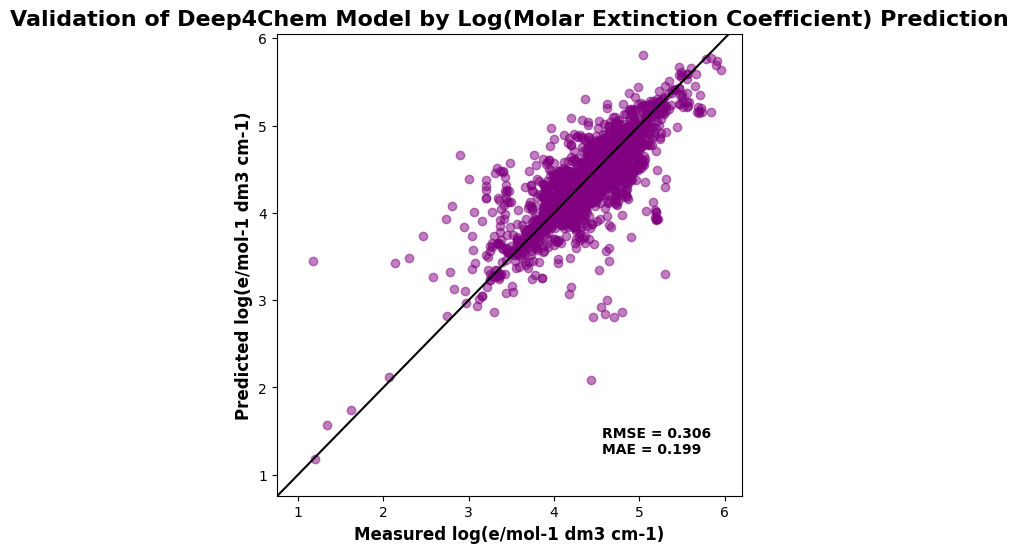

In [27]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(true_log_mec, pred_log_mec, alpha=0.5, color='purple')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Deep4Chem Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean (ensemble) evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {np.mean(log_mec_rmse_preds):.3f}\nMAE = {np.mean(log_mec_mae_preds):.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

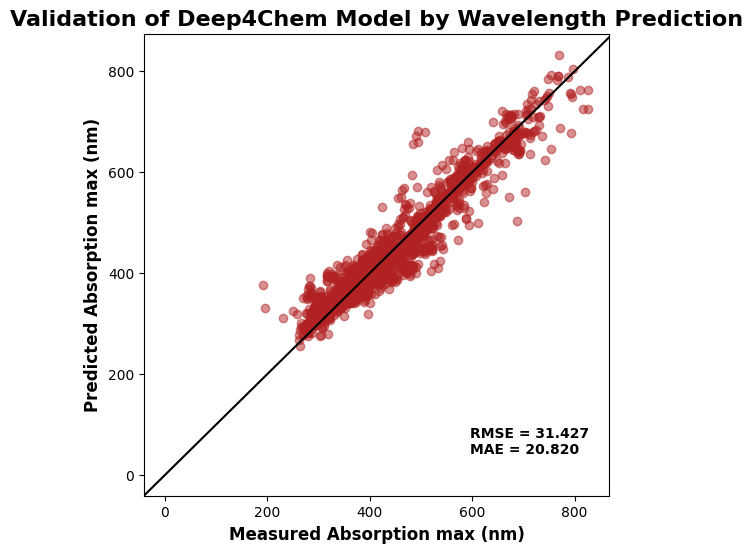

In [28]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(true_wavelength, pred_wavelength, alpha=0.5, color='firebrick')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Deep4Chem Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean (ensemble) evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {np.mean(wavelength_rmse_preds):.3f}\nMAE = {np.mean(wavelength_mae_preds):.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

### Comments:

Resulting averaged (mean) prediction file is the same as the outputted prediction file using all (10) models from 200 epoch, 10-fold cross-validation training - prediction was performed on the test subset by each model individually after initially iterating through models in one prediction command (outputted results was the average of each, so evaluation metrics could not be obtained using the provided method), and the 'preds_path' argument can be set so that each set of predictions can be gathered and analysed simply

Invalid SMILES errors were caused by the solvent entry "gas" - only 3 datapoints contained this so simply removed as this is difficult to interpret and likely would not have a large impact on resulting evaluation metrics

Additional evaluation metrics can be calculated and added to scatter plot as required (e.g. R2 score)

## **HPC-Based Replication**

In [73]:
# loading test Deep4Chem dataset and Chemprop predictions obtained utilising the HPC cluster
test = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/HPC_d4c_chemprop/real_predictions/d4c_test.csv')
hpc_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/HPC_d4c_chemprop/real_predictions/ensemble_preds.csv')

In [74]:
# definint valid rows in the test subset to be those which do not include invalid solvent SMILES inputs (= "gas")
valid = test['Solvent'] != 'gas'
# reducing test subset and ensemble/model predictions to exclude invalid input rows
test = test.loc[valid].reset_index(drop=True)
hpc_preds = hpc_preds.loc[valid].reset_index(drop=True)

# specifying columns within the ensemble/individual prediction outputs file which are related to wavelength and log(molar extinction coefficient),
# respectively
wavelength_cols = [c for c in hpc_preds.columns if 'Absorption max (nm)_model_' in c]
log_cols = [c for c in hpc_preds.columns if 'log(e/mol-1 dm3 cm-1)_model_' in c]

# converting string values to numeric (float) values for both predicted target properties' columns
hpc_preds['Absorption max (nm)'] = (hpc_preds[wavelength_cols].astype(float).mean(axis=1))
hpc_preds['log(e/mol-1 dm3 cm-1)'] = (hpc_preds[log_cols].astype(float).mean(axis=1))

In [75]:
# creating lists to store evaluation metrics for predicted wavelength values
hpc_wavelength_rmse = []
hpc_wavelength_mae = []

# creating lists to store evaluation metrics for predicted log(molar extinction coefficient) values
hpc_log_mec_rmse = []
hpc_log_mec_mae = []

# iterating through prediction files
for i in range(10):
    # splitting predicted values for both targets into separate variables
    hpc_pred_wavelength = hpc_preds[f'Absorption max (nm)_model_{i}']
    hpc_pred_log_mec = hpc_preds[f'log(e/mol-1 dm3 cm-1)_model_{i}']

    # calculating evaluation metrics for wavelength into separate lists
    hpc_wavelength_rmse.append(np.sqrt(mean_squared_error(true_wavelength, hpc_pred_wavelength)))
    hpc_wavelength_mae.append(mean_absolute_error(true_wavelength, hpc_pred_wavelength))

    # calculating evaluation metrics for log(molar extinction coefficient) into separate lists
    hpc_log_mec_rmse.append(np.sqrt(mean_squared_error(true_log_mec, hpc_pred_log_mec)))
    hpc_log_mec_mae.append(mean_absolute_error(true_log_mec, hpc_pred_log_mec))

# calculating (ensemble) evaluation metrics for wavelength across all 10 models
ensemble_wavelength_rmse = np.sqrt(mean_squared_error(true_wavelength, hpc_preds['Absorption max (nm)']))
ensemble_wavelength_mae = mean_absolute_error(true_wavelength, hpc_preds['Absorption max (nm)'])

# calculating (ensemble) evaluation metrics for log(molar extinction coefficient) across all 10 models
ensemble_log_mec_rmse = np.sqrt(mean_squared_error(true_log_mec, hpc_preds['log(e/mol-1 dm3 cm-1)']))
ensemble_log_mec_mae = mean_absolute_error(true_log_mec, hpc_preds['log(e/mol-1 dm3 cm-1)'])

# calculating (ensemble) standard deviations for both wavelength error metrics across all models
ensemble_wavelength_rmse_sd = np.std(hpc_wavelength_rmse)
ensemble_wavelength_mae_sd = np.std(hpc_wavelength_mae)

# calculating (ensemble) standard deviations for both log(molar extinction coefficient) error metrics across all models
ensemble_log_mec_rmse_sd = np.std(hpc_log_mec_rmse)
ensemble_log_mec_mae_sd = np.std(hpc_log_mec_mae)

In [76]:
# printing evaluation metrics for both target properties
print('HPC Wavelength RMSE:', ensemble_wavelength_rmse, '+/-', ensemble_wavelength_rmse_sd)
print('HPC Wavelength MAE:', ensemble_wavelength_mae, '+/-', ensemble_wavelength_mae_sd)

print('\nHPC Log(molar extinction coefficient) RMSE:', ensemble_log_mec_rmse, '+/-', ensemble_log_mec_rmse_sd)
print('HPC Log(molar extinction coefficient) MAE:', ensemble_log_mec_mae,'+/-', ensemble_log_mec_mae_sd)

HPC Wavelength RMSE: 29.711841633814046 +/- 0.9174482363634983
HPC Wavelength MAE: 19.243261064982665 +/- 0.7274746464600399

HPC Log(molar extinction coefficient) RMSE: 0.2910310682764498 +/- 0.006042145861842859
HPC Log(molar extinction coefficient) MAE: 0.18802229750872265 +/- 0.0025115285969185665


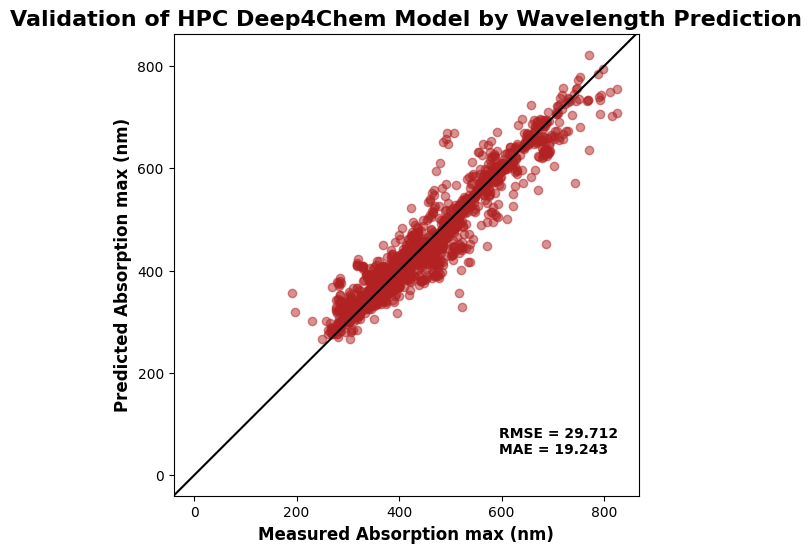

In [77]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(true_wavelength, hpc_pred_wavelength, alpha=0.5, color='firebrick')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of HPC Deep4Chem Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_wavelength_rmse:.3f}\nMAE = {ensemble_wavelength_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

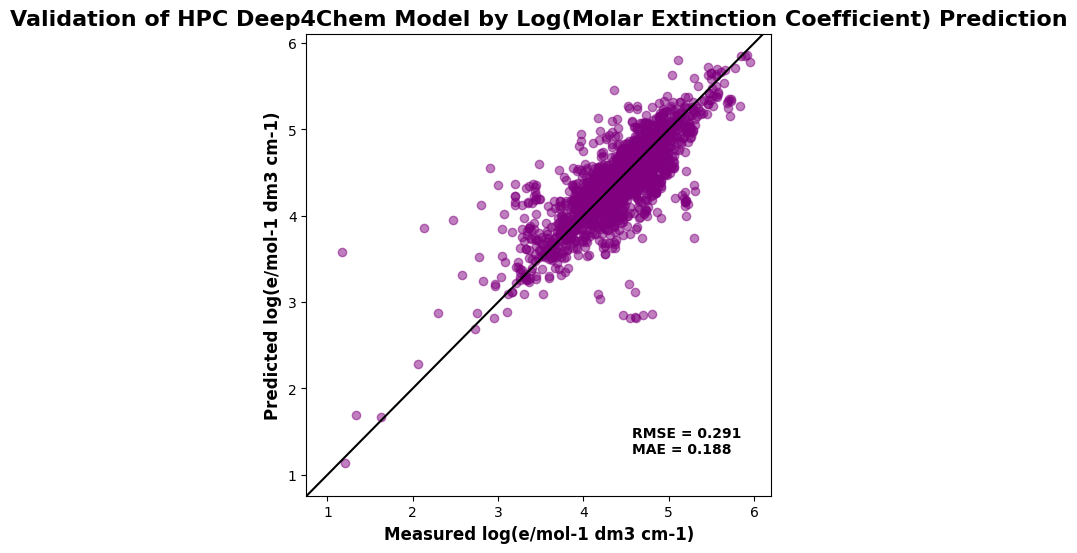

In [78]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(true_log_mec, hpc_pred_log_mec, alpha=0.5, color='purple')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of HPC Deep4Chem Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_log_mec_rmse:.3f}\nMAE = {ensemble_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

### Comments:

Same process executed on the HPC returned slightly lower outputted metrics, exceeding the lower standard deviation bounds by the Google Colab experiments' results - reduction not as drastic as e.g. authors' errors vs. my Google Colab errors, will accept this as further general methodology validation and attribute output differences to environmental changes and inherent random chance between deep learning models

Simpler, shorter analysis workflow possible when specifying the ensemble predictions CSV should include individual model predictions during the prediction command

